<a href="https://colab.research.google.com/github/vallabh77881/BML-LCA-/blob/main/lca_skill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Drive Mount

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
csv_path1 = '/content/drive/My Drive/Datasets/5%/UNSW_2018_IoT_Botnet_Full5pc_1.csv'
csv_path2 = '/content/drive/My Drive/Datasets/5%/UNSW_2018_IoT_Botnet_Full5pc_2.csv'
csv_path3 =  '/content/drive/My Drive/Datasets/5%/UNSW_2018_IoT_Botnet_Full5pc_3.csv'
csv_path4 = '/content/drive/My Drive/Datasets/5%/UNSW_2018_IoT_Botnet_Full5pc_4.csv'

In [ ]:
df1 = pd.read_csv(csv_path1)
df2 = pd.read_csv(csv_path2)
df3 = pd.read_csv(csv_path3)
df4 = pd.read_csv(csv_path4)

<ipython-input-119-fbdf8ffebe90>:1: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(csv_path1)
<ipython-input-119-fbdf8ffebe90>:2: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv(csv_path2)
<ipython-input-119-fbdf8ffebe90>:3: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv(csv_path3)
<ipython-input-119-fbdf8ffebe90>:4: DtypeWarning: Columns (7,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df4 = pd.read_csv(csv_path4)


In [ ]:
df_merged = pd.concat([df1, df2, df3, df4], ignore_index=True)

#1:Import Dataset

In [ ]:
import pandas as pd

df = df_merged.sample(n=100000, random_state=42)

In [ ]:
df.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
995784,995785,1.528085e+09,e,1,udp,3,192.168.100.147,54755,192.168.100.7,80,...,0.404198,78,78,0.404232,0.375505,858,858,1,DoS,UDP
170580,170581,1.528081e+09,e s,2,tcp,1,192.168.100.148,49784,192.168.100.6,80,...,0.199519,100,100,0.209578,0.199519,346,346,1,DoS,TCP
3141497,3141498,1.528099e+09,e,1,udp,3,192.168.100.150,5522,192.168.100.3,80,...,0.556383,100,95,0.576999,0.556383,675,640,1,DDoS,UDP
2925715,2925716,1.528099e+09,e,1,udp,3,192.168.100.150,19913,192.168.100.3,80,...,0.536848,100,100,0.494465,0.536848,760,760,1,DDoS,UDP
3614039,3614040,1.526345e+09,e,1,tcp,1,192.168.100.148,53188,192.168.100.3,110,...,30.319200,100,25,68.357800,42.136800,152,20,1,Reconnaissance,Service_Scan


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 995784 to 2210748
Data columns (total 46 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   pkSeqID                           100000 non-null  int64  
 1   stime                             100000 non-null  float64
 2   flgs                              100000 non-null  object 
 3   flgs_number                       100000 non-null  int64  
 4   proto                             100000 non-null  object 
 5   proto_number                      100000 non-null  int64  
 6   saddr                             100000 non-null  object 
 7   sport                             100000 non-null  object 
 8   daddr                             100000 non-null  object 
 9   dport                             100000 non-null  object 
 10  pkts                              100000 non-null  int64  
 11  bytes                             100000 non-null  

In [ ]:
df.size

4600000

In [ ]:
df.shape

(100000, 46)

#2:Data Preprocessing - Cleaning dataset

In [ ]:
print(df.duplicated().sum())


0


In [ ]:
df.isna().sum()

,0
pkSeqID,0
stime,0
flgs,0
flgs_number,0
proto,0
proto_number,0
saddr,0
sport,0
daddr,0
dport,0


In [ ]:
df.isnull().sum()

,0
pkSeqID,0
stime,0
flgs,0
flgs_number,0
proto,0
proto_number,0
saddr,0
sport,0
daddr,0
dport,0


## Fixing outliers

In [ ]:
from scipy.stats.mstats import winsorize

numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

for col in numerical_cols:
    df[col] = winsorize(df[col], limits=[0.05, 0.05])

#3: Apply encoding techniques.

##• Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

temp_label = df.copy()
le = LabelEncoder()

for col in temp_label.columns:
    if temp_label[col].dtype == 'object':
        temp_label[col] = temp_label[col].astype(str)
        temp_label[col] = le.fit_transform(temp_label[col])
temp_label.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
995784,995785,1.528085e+09,0,1,3,3,0,38804,8,1317,...,0.404198,78,78,0.404232,0.375505,858,858,1,1,5
170580,182811,1.528081e+09,4,2,2,1,1,34429,7,1317,...,0.199519,100,100,0.209578,0.199519,346,346,1,1,4
3141497,3141498,1.528099e+09,0,1,3,3,3,39200,5,1317,...,0.556383,100,95,0.576999,0.556383,675,640,1,0,5
2925715,2925716,1.528099e+09,0,1,3,3,3,8597,5,1317,...,0.536848,100,100,0.494465,0.536848,760,760,1,0,5
3614039,3480538,1.528081e+09,0,1,2,1,1,37408,5,323,...,13.854200,100,30,9.606700,11.333600,152,90,1,3,3


#5 & 6:Visualization

##Bar Graph

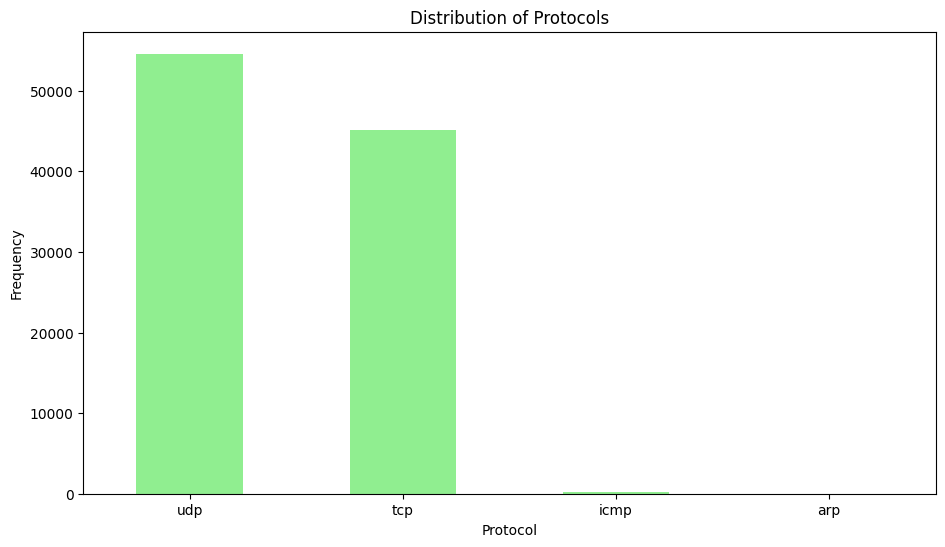

In [ ]:
import matplotlib.pyplot as plt

proto_counts = df['proto'].value_counts()
plt.figure(figsize=(11, 6))
proto_counts.plot(kind='bar', color='lightgreen')
plt.title('Distribution of Protocols')
plt.xlabel('Protocol')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

## Pie Chart

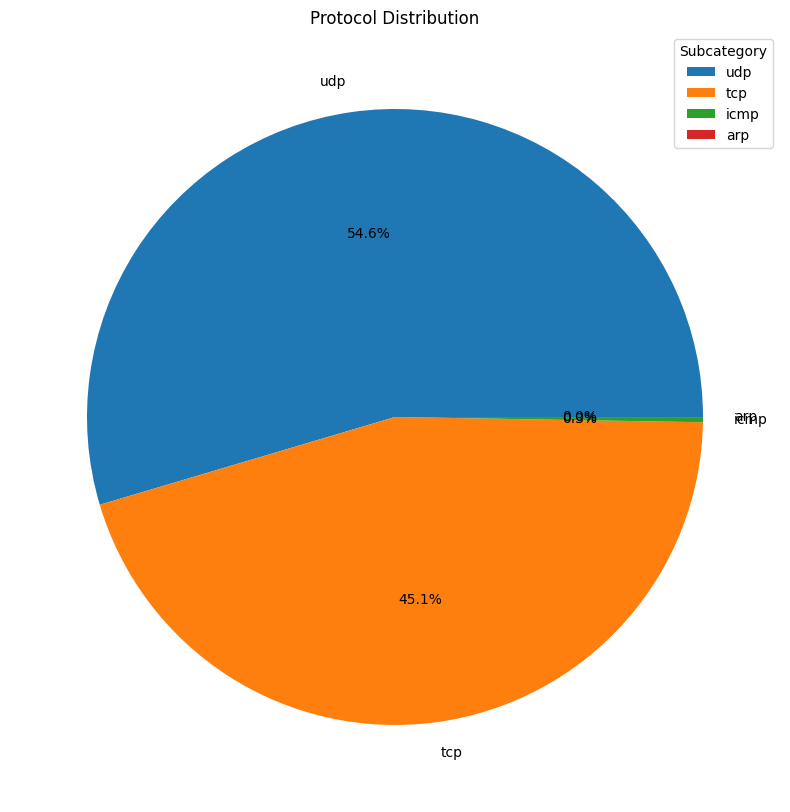

In [ ]:
subcat_names = df["proto"].value_counts().index
subcat_vals = df["proto"].value_counts().values
plt.figure(figsize=(10, 10))
plt.pie(subcat_vals, labels=subcat_names, autopct='%1.1f%%')
plt.legend(subcat_names, title='Subcategory', loc='upper right')
plt.title('Protocol Distribution')
plt.show()

## Histogram

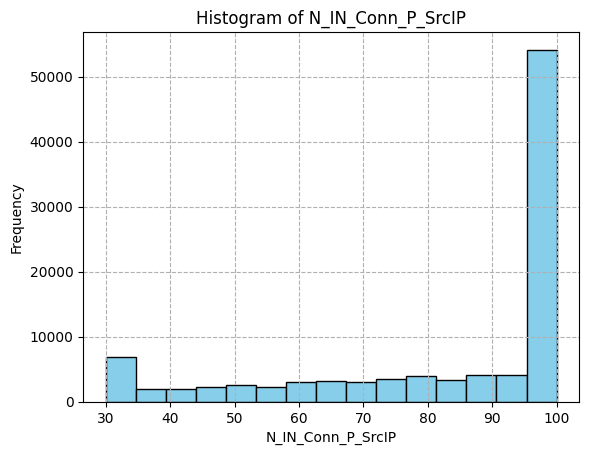

In [ ]:
plt.hist(df['N_IN_Conn_P_SrcIP'], bins=15, color='skyblue', edgecolor='black')
plt.title('Histogram of N_IN_Conn_P_SrcIP')
plt.xlabel('N_IN_Conn_P_SrcIP')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--')
plt.show()

## Box Plot

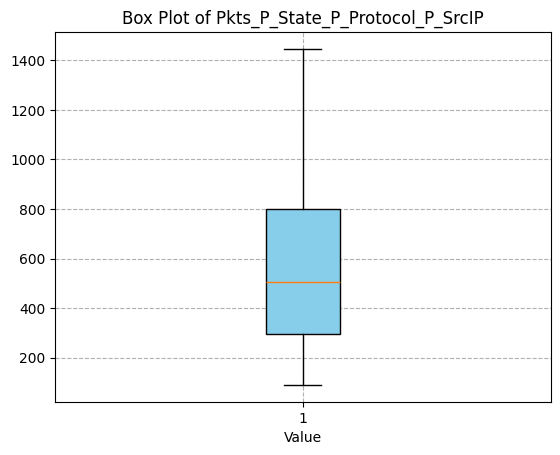

In [ ]:

plt.boxplot(df['Pkts_P_State_P_Protocol_P_SrcIP'], patch_artist=True,
            boxprops=dict(facecolor='skyblue', color='black'),
            flierprops=dict(markerfacecolor='orange', marker='o', markersize=5))
plt.title('Box Plot of Pkts_P_State_P_Protocol_P_SrcIP')
plt.xlabel('Value')
plt.grid(True, linestyle='--')
plt.show()

# 4: Data preprocessing- Normalization

##Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

temp_standardization = df.copy()
numeric_columns = temp_standardization.select_dtypes(include=['float64', 'int64']).columns
for column in numeric_columns:
    temp_standardization[column] = scaler.fit_transform(temp_standardization[[column]])
temp_standardization.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
995784,-0.808901,-0.824644,e,-0.770273,udp,0.906981,192.168.100.147,54755,192.168.100.7,80,...,-0.256036,-1.008129,-0.219949,-0.241083,-0.258904,0.573120,0.734326,0.0,DoS,UDP
170580,-1.589146,-1.326598,e s,1.298241,tcp,-1.102615,192.168.100.148,49784,192.168.100.6,80,...,-0.322305,0.438590,0.734957,-0.336326,-0.330930,-0.770272,-0.634729,0.0,DoS,TCP
3141497,1.250430,1.167315,e,-0.770273,udp,0.906981,192.168.100.150,5522,192.168.100.3,80,...,-0.206762,0.438590,0.517933,-0.156550,-0.184875,0.092962,0.151408,0.0,DDoS,UDP
2925715,1.043335,1.167069,e,-0.770273,udp,0.906981,192.168.100.150,19913,192.168.100.3,80,...,-0.213087,0.438590,0.734957,-0.196933,-0.192870,0.315987,0.472281,0.0,DDoS,UDP
3614039,1.575821,-1.327107,e,-0.770273,tcp,-1.102615,192.168.100.148,53188,192.168.100.3,110,...,4.098708,0.438590,-2.303379,4.261596,4.225971,-1.279292,-1.319256,0.0,Reconnaissance,Service_Scan


# 7 & 8 :  Methods Of Feature Selection

## Forward Selection

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

df_sampled = df.sample(n=5000, random_state=42)
x = df_sampled.select_dtypes(include='number')

df_sampled['subcategory_encoded'] = le.fit_transform(df_sampled['subcategory'])
y = df_sampled['subcategory_encoded']
model = LogisticRegression(max_iter=1000)
sfs = SequentialFeatureSelector(
    estimator=model,
    direction='forward',
    n_features_to_select=5,
    scoring='accuracy',
    cv=2,
    n_jobs=-1

)

sfs.fit(x, y)

selected_features = x.columns[sfs.get_support()]
print("Features selected by Forward Selection:\n")
print(selected_features)

Features selected by Forward Selection:

Index(['pkSeqID', 'proto_number', 'dur', 'stddev', 'rate'], dtype='object')


## L1 Regularization

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model.fit(x, y)
coef_abs = np.abs(model.coef_[0])

top_indices = np.argsort(coef_abs)[-5:][::-1]

top_features = x.columns[top_indices]

print("Top 5 Features :")
print(top_features)


Top 5 Features :
Index(['TnP_PSrcIP', 'Pkts_P_State_P_Protocol_P_DestIP', 'TnP_Per_Dport',
       'TnP_PerProto', 'bytes'],
      dtype='object')


# 12 :Model Implementation & Ensemble Learning

## Model

### Spliting

In [ ]:
from sklearn.model_selection import train_test_split

df_copy = df.copy()
X = df_copy[['pkts', 'bytes', 'dur', 'rate', 'srate', 'drate', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'proto_number', 'state_number', 'N_IN_Conn_P_DstIP']]
le = LabelEncoder()
df_copy['subcategory_encoded'] = le.fit_transform(df_copy['subcategory'])
y = df_copy['subcategory_encoded']
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

print(f"Train set size: {X_train.shape} samples")
print(f"Test set size: {X_test.shape} samples")

Train set size: (80000, 13) samples
Test set size: (20000, 13) samples


### Linear Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9933


## Ensemble Learning

### Boosting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
base_model = DecisionTreeClassifier()

boosting_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=10,
    random_state=42
)

boosting_model.fit(X_train, y_train)
y_pred = boosting_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of AdaBoost Model: {accuracy:.4f}")

Accuracy of AdaBoost Model: 0.9947
